
# DATA Diafiltration: Common-Anion Multicomponent Model (Notebook)

This notebook implements a well-mixed DATA diafiltration model (retentate tank + flat-sheet membrane area A)
for a solution with multiple cations and a common anion.

We implement only:
- Partitioning (solution ↔ membrane interface): Eqs. 85–86 (log form).
- Membrane transport: Eq. 113 with coefficients from 115–118 (alpha_i, D_ij, D_tilde).
- Anion flux coupling: Eq. 114.
- Water flux (Tr-II): $J_w$ = $L_p (\Delta P - \Delta p_i)$

DATA geometry: well-mixed retentate, membrane area A, permeate normal to the surface (no axial gradients).



## Equations implemented (summary)

Interface partitioning (common anion), $Eqs. 85–86$ (log form):
$z_i (\log H_a - \log c_a^m + \log c_a^s) = z_a (\log H_i - \log c_i^m + \log c_i^s), \forall~i~in~C$,
$\chi + \sum_j z_j c_j^m = 0$.

Membrane fluxes, $Eq. 113$, with anion coupling $Eq. 114$:
$j_i = \alpha_i c_i^m Jw + sum_{j in C} D_ij grad(c_j^m), i \in C$,
$j_a = - \sum_{j in C} (z_j / z_a) j_j$.

Coefficients ($Eqs. 115–118$):
$\alpha_i = 1 + (z_i D_i^m \chi) / \tilde{D}$,
$\tilde{D} = \sum_{j in C} (z_j^2 D_j^m - z_j z_a D_a^m) c_j^m - z_a D_a^m \chi$,
$D_{ij} = {
  [(z_i z_j D_i^m D_j^m - z_i z_j D_i^m D_a^m) c_i^m] / \tilde{D},~if~i~!=~j
  [ \sum_{k in C} (z_k z_a D_i^m D_a^m - beta_ik) c_k^m + z_a D_i^m D_a^m \chi ] / \tilde{D},~if~i = j
}$
with $\beta_{ik} = z_k^2 D_k^m D_i^m~for~i~!=~k$, and $\beta_{ik} = z_k^2 D_k^m D_a^m~for~i = k$.

Water flux ($Tr-II$): $Jw = Lp (\Delta P - \Delta \pi)$.

DATA balances (well-mixed):
$dV/dt = -A Jw$, and $d/dt (V c_i) = -A j_i  =>  dc_i/dt = (-A j_i - c_i dV/dt) / V$.


## Imports

In [1]:

import numpy as np
from dataclasses import dataclass
from typing import Tuple
from numpy.linalg import solve as lin_solve
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt



## Setup and units

SI units:
- D^m: m^2/s;  DeltaP: Pa;  Lp: m/(s*Pa) => Jw in m/s;  c: kg/m^3
- MW: kg/mol (only to compute a minimal van't Hoff Deltapi)


In [2]:

@dataclass
class Setup:
    # Geometry / operation
    A: float                 # membrane area [m^2]
    V0: float                # initial retentate volume [m^3]
    delta: float             # effective transport thickness for grad c [m]
    # Electrolyte & transport props
    z_c: np.ndarray          # cation valences, shape (n,)
    z_a: int                 # anion valence (negative)
    Dm_c: np.ndarray         # membrane-phase diffusivities of cations [m^2/s], shape (n,)
    Dm_a: float              # membrane-phase diffusivity of anion [m^2/s]
    H_c: np.ndarray          # partition coefficients (cations), shape (n,)
    H_a: float               # partition coefficient (anion)
    chi: float               # membrane fixed charge density [same units as c]
    # Water flux & thermodynamics
    Lp: float                # hydraulic permeability [m/(s*Pa)]
    dP: float                # transmembrane pressure drop [Pa]
    R: float                 # gas constant [J/(mol*K)]
    T: float                 # temperature [K]
    MW_c: np.ndarray         # molecular weights cations [kg/mol], shape (n,)
    MW_a: float              # anion MW [kg/mol]



## Step 1 — Partitioning (Eqs. 85–86, log form)

Solve for membrane-side interfacial concentrations (c_i^m, c_a^m) from solution-side values (c_i^s, c_a^s).
Use a damped Newton method with finite-difference Jacobian.


In [3]:

def partition_common_anion_log(
    c_s_c: np.ndarray, c_s_a: float,
    H_c: np.ndarray, H_a: float,
    z_c: np.ndarray, z_a: int, chi: float,
    tol: float = 1e-11, maxit: int = 30
) -> Tuple[np.ndarray, float]:
    n = len(c_s_c)
    # Positive initial guess
    x = np.hstack([np.maximum(c_s_c/np.maximum(H_c,1.0),1e-12),
                   np.maximum(c_s_a/max(H_a,1.0),1e-12)])

    def residual(x):
        c_m_c = np.clip(x[:n], 1e-30, None)
        c_m_a = max(x[-1], 1e-30)
        eq = z_c*(np.log(H_a) - np.log(c_m_a) + np.log(c_s_a))            -  z_a*(np.log(H_c) - np.log(c_m_c) + np.log(c_s_c))
        en = chi + (z_c @ c_m_c) + z_a*c_m_a
        return np.hstack([eq, en])

    for _ in range(maxit):
        r = residual(x)
        if np.linalg.norm(r) < tol: break
        J = np.zeros((n+1, n+1))
        eps = 1e-8
        for k in range(n+1):
            xk = x.copy(); xk[k] *= (1+eps)
            J[:,k] = (residual(xk) - r) / (xk[k] - x[k])
        try:
            dx = lin_solve(J, -r)
        except np.linalg.LinAlgError:
            dx = -1e-2*r
        lam = 1.0
        for _ in range(8):
            xt = x + lam*dx
            if np.all(xt>0) and np.linalg.norm(residual(xt)) < np.linalg.norm(r):
                x = xt; break
            lam *= 0.5
    return x[:n], x[-1]



## Step 2 — Compute alpha_i, D_ij, and D_tilde (Eqs. 115–118)


In [4]:

def compute_alpha_D(c_m_c, z_c, z_a, Dm_c, Dm_a, chi):
    # Eq. 118
    D_tilde = np.sum((z_c**2 * Dm_c - z_c*z_a*Dm_a) * c_m_c) - z_a*Dm_a*chi
    # Eq. 115
    alpha = 1.0 + (z_c * Dm_c * chi) / D_tilde
    # Eq. 116–117
    n = len(z_c)
    Dmat = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            if i != j:
                Dmat[i,j] = ((z_c[i]*z_c[j]*Dm_c[i]*Dm_c[j] - z_c[i]*z_c[j]*Dm_c[i]*Dm_a) * c_m_c[i]) / D_tilde
            else:
                beta_sum = 0.0
                for k in range(n):
                    if i != k:
                        beta_ik = (z_c[k]**2) * Dm_c[k] * Dm_c[i]
                    else:
                        beta_ik = (z_c[k]**2) * Dm_c[k] * Dm_a
                    beta_sum += beta_ik * c_m_c[k]
                Dmat[i,i] = (np.sum((z_c * z_a * Dm_c[i] * Dm_a) * c_m_c)
                             - beta_sum + z_a*Dm_c[i]*Dm_a*chi) / D_tilde
    return alpha, Dmat, D_tilde



## Step 3 — Water flux (Tr-II) and minimal Deltapi


In [5]:

def osmotic_pressure_RT(c_s_c, c_s_a, MW_c, MW_a, R, T):
    mol_c = c_s_c / MW_c
    mol_a = c_s_a / MW_a
    return R*T*(np.sum(mol_c) + mol_a)

def water_flux(Lp, dP, dPi):
    return Lp * max(dP - dPi, 0.0)



## Step 4 — DATA balances (well-mixed)


In [6]:

def rhs_data(t, y, S: Setup):
    n = len(S.z_c)
    V = y[0]
    c_c = np.clip(y[1:1+n], 1e-30, None)
    c_a = max(y[1+n], 1e-30)

    # 1) Partitioning
    c_m_c, c_m_a = partition_common_anion_log(c_c, c_a, S.H_c, S.H_a, S.z_c, S.z_a, S.chi)

    # 2) Transport coefficients
    alpha, Dmat, D_tilde = compute_alpha_D(c_m_c, S.z_c, S.z_a, S.Dm_c, S.Dm_a, S.chi)

    # 3) Gradient closure
    grad_c_m = -(c_m_c / S.delta)

    # 4) Water flux
    dPi = osmotic_pressure_RT(c_c, c_a, S.MW_c, S.MW_a, S.R, S.T)
    Jw = water_flux(S.Lp, S.dP, dPi)

    # 5) Fluxes and anion coupling
    j_c = alpha * c_m_c * Jw + Dmat @ grad_c_m
    j_a = -np.dot(S.z_c, j_c) / S.z_a

    # 6) Well-mixed balances
    dVdt = - S.A * Jw
    dVc_c_dt = - S.A * j_c
    dVc_a_dt = - S.A * j_a
    denom = max(V, 1e-18)
    dc_c_dt = (dVc_c_dt - c_c*dVdt) / denom
    dc_a_dt = (dVc_a_dt - c_a*dVdt) / denom

    return np.hstack([dVdt, dc_c_dt, dc_a_dt])



## Step 5 — Example: Li+, Co2+, Cl-


In [7]:

# Example configuration
z_c = np.array([+1.0, +2.0])
z_a = -1

S = Setup(
    A=0.005, V0=0.05, delta=1e-7,
    z_c=z_c, z_a=z_a,
    Dm_c=np.array([1.0e-10, 7.0e-11]),
    Dm_a=2.0e-10,
    H_c=np.array([1.1, 0.9]), H_a=0.95,
    chi=0.0,
    Lp=1.5e-11, dP=5.0e5,
    R=8.314, T=298.15,
    MW_c=np.array([0.00694, 0.05893]),
    MW_a=0.03545
)

# Initial retentate composition [kg/m^3], electroneutral in solution
c1_0, c2_0 = 1.0, 5.0
c_a0 = -(z_c[0]*c1_0 + z_c[1]*c2_0)/z_a

y0 = np.hstack([S.V0, [c1_0, c2_0], c_a0])
t_span = (0.0, 3600.0)  # 1 hour
t_eval = np.linspace(*t_span, 401)

sol = solve_ivp(lambda t,y: rhs_data(t,y,S), t_span, y0, t_eval=t_eval,
                rtol=1e-7, atol=1e-10)
if not sol.success:
    raise RuntimeError(sol.message)

t = sol.t
V = sol.y[0]
c_c = sol.y[1:1+len(z_c), :]
c_a = sol.y[1+len(z_c), :]

print("Finished. Final volume [m^3]:", V[-1])
print("Final cations [kg/m^3]:", c_c[:, -1])
print("Final anion [kg/m^3]:", c_a[-1])


Finished. Final volume [m^3]: 0.05
Final cations [kg/m^3]: [0.57559591 3.32471939]
Final anion [kg/m^3]: 7.225034689776375



## Step 6 — Plots


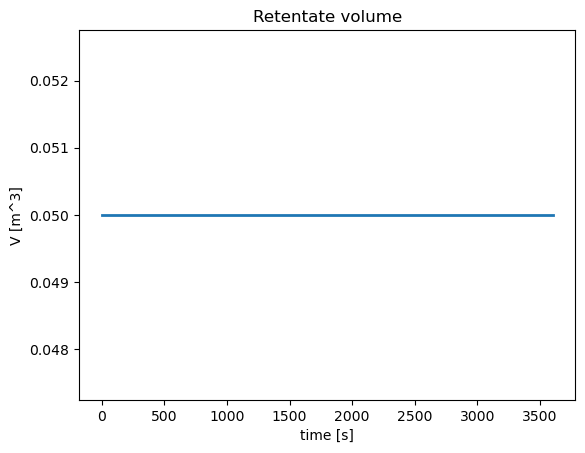

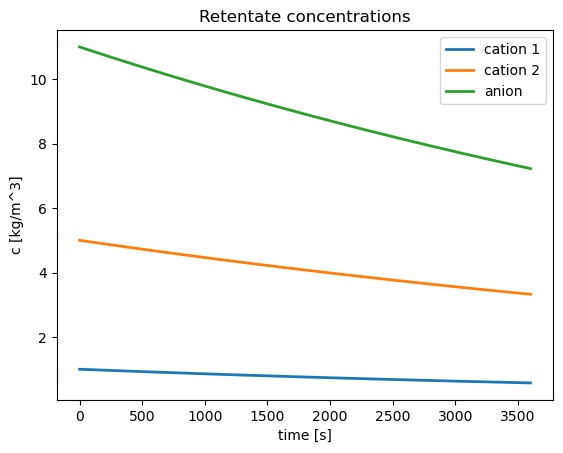

In [8]:

# Volume
plt.figure()
plt.plot(t, V, linewidth=2)
plt.xlabel("time [s]")
plt.ylabel("V [m^3]")
plt.title("Retentate volume")
plt.show()

# Concentrations
plt.figure()
for i in range(c_c.shape[0]):
    plt.plot(t, c_c[i], linewidth=2, label=f"cation {i+1}")
plt.plot(t, c_a, linewidth=2, label="anion")
plt.xlabel("time [s]")
plt.ylabel("c [kg/m^3]")
plt.title("Retentate concentrations")
plt.legend()
plt.show()



## Step 7 — How to adapt
- Replace D_i^m, H_i, chi, Lp, and DeltaP with your fitted values.
- If you measure permeate compositions, replace grad c_i^m approx -c_i^m/delta with a two-point gradient.
- To add a third cation, extend arrays (z_c, Dm_c, H_c, MW_c) and initial conditions.
